# AREPO: First Inspection

AREPO uses a **moving mesh**: the gas lives in Voronoi cells that move with the flow, so there is
no fixed grid and no refinement level. Each cell is a point that knows how much space it occupies.

The run is a cluster merger, about 13 million gas cells in a 40 Mpc box.

!!! note "You can download this snapshot"
    It is the `ArepoBullet` sample from the yt project:

    ```bash
    curl -O https://yt-project.org/data/ArepoBullet.tar.gz
    tar xzf ArepoBullet.tar.gz
    ```


## 1. What is in the file?


In [1]:
using Mera, CairoMakie

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/AREPO/ArepoBullet/ArepoBullet"
info = getinfo(150, path);



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v2.0.0-DEV | Julia 1.12.7 | 8 threads

[Mera]: 2026-09-15T22:03:06.416



Code: AREPO
output: 150  time: 1.5381  redshift: 0.0
boxlen = 40000.0
cells/particles: 

12865831 gas cells (Voronoi), 13368238 halo/DM, 295531 stars  (total 26529600)
gas is PartType0 → load with getparticles(info, families=[0]); there is no separate hydro block
group catalogue: none found  (halo membership via halo= unavailable)
-------------------------------------------------------
[Mera]: composition not recorded by this format; using X = 0.76, mu = 1.32 (RAMSES convention) for :nH and :T. Change with setcomposition!(info; X_frac=…, mu=…).

A census of the whole snapshot in one call, before loading anything yourself:


In [2]:
ql = quicklook(150; path=path);


[Mera]: quicklook output 150, reading particles: 2026-09-15T22:03:21.999



┌─ Mera quicklook ── output 150 (AREPO) ───────────────


│ box        : 40000.0 kpc      levels 1–1  (finest 2.0e7 pc)
│ grid       : ndim 3 · ncpu 1 · nvarh 0
│ time       : 1504.0 Myr  (non-cosmological)
│ particles  : 13368242 total  —  stars 0 · DM 13368238 · sinks 4
│ star mass  : 0.0 M⊙        DM mass : 9.049e14 M⊙
│ current SFR: — (10 Myr) · — (100 Myr) M⊙/yr
└─ 17.27 s ──────────────────────────────────
[Mera]: quicklook output 150 finished: 2026-09-15T22:03:39.267



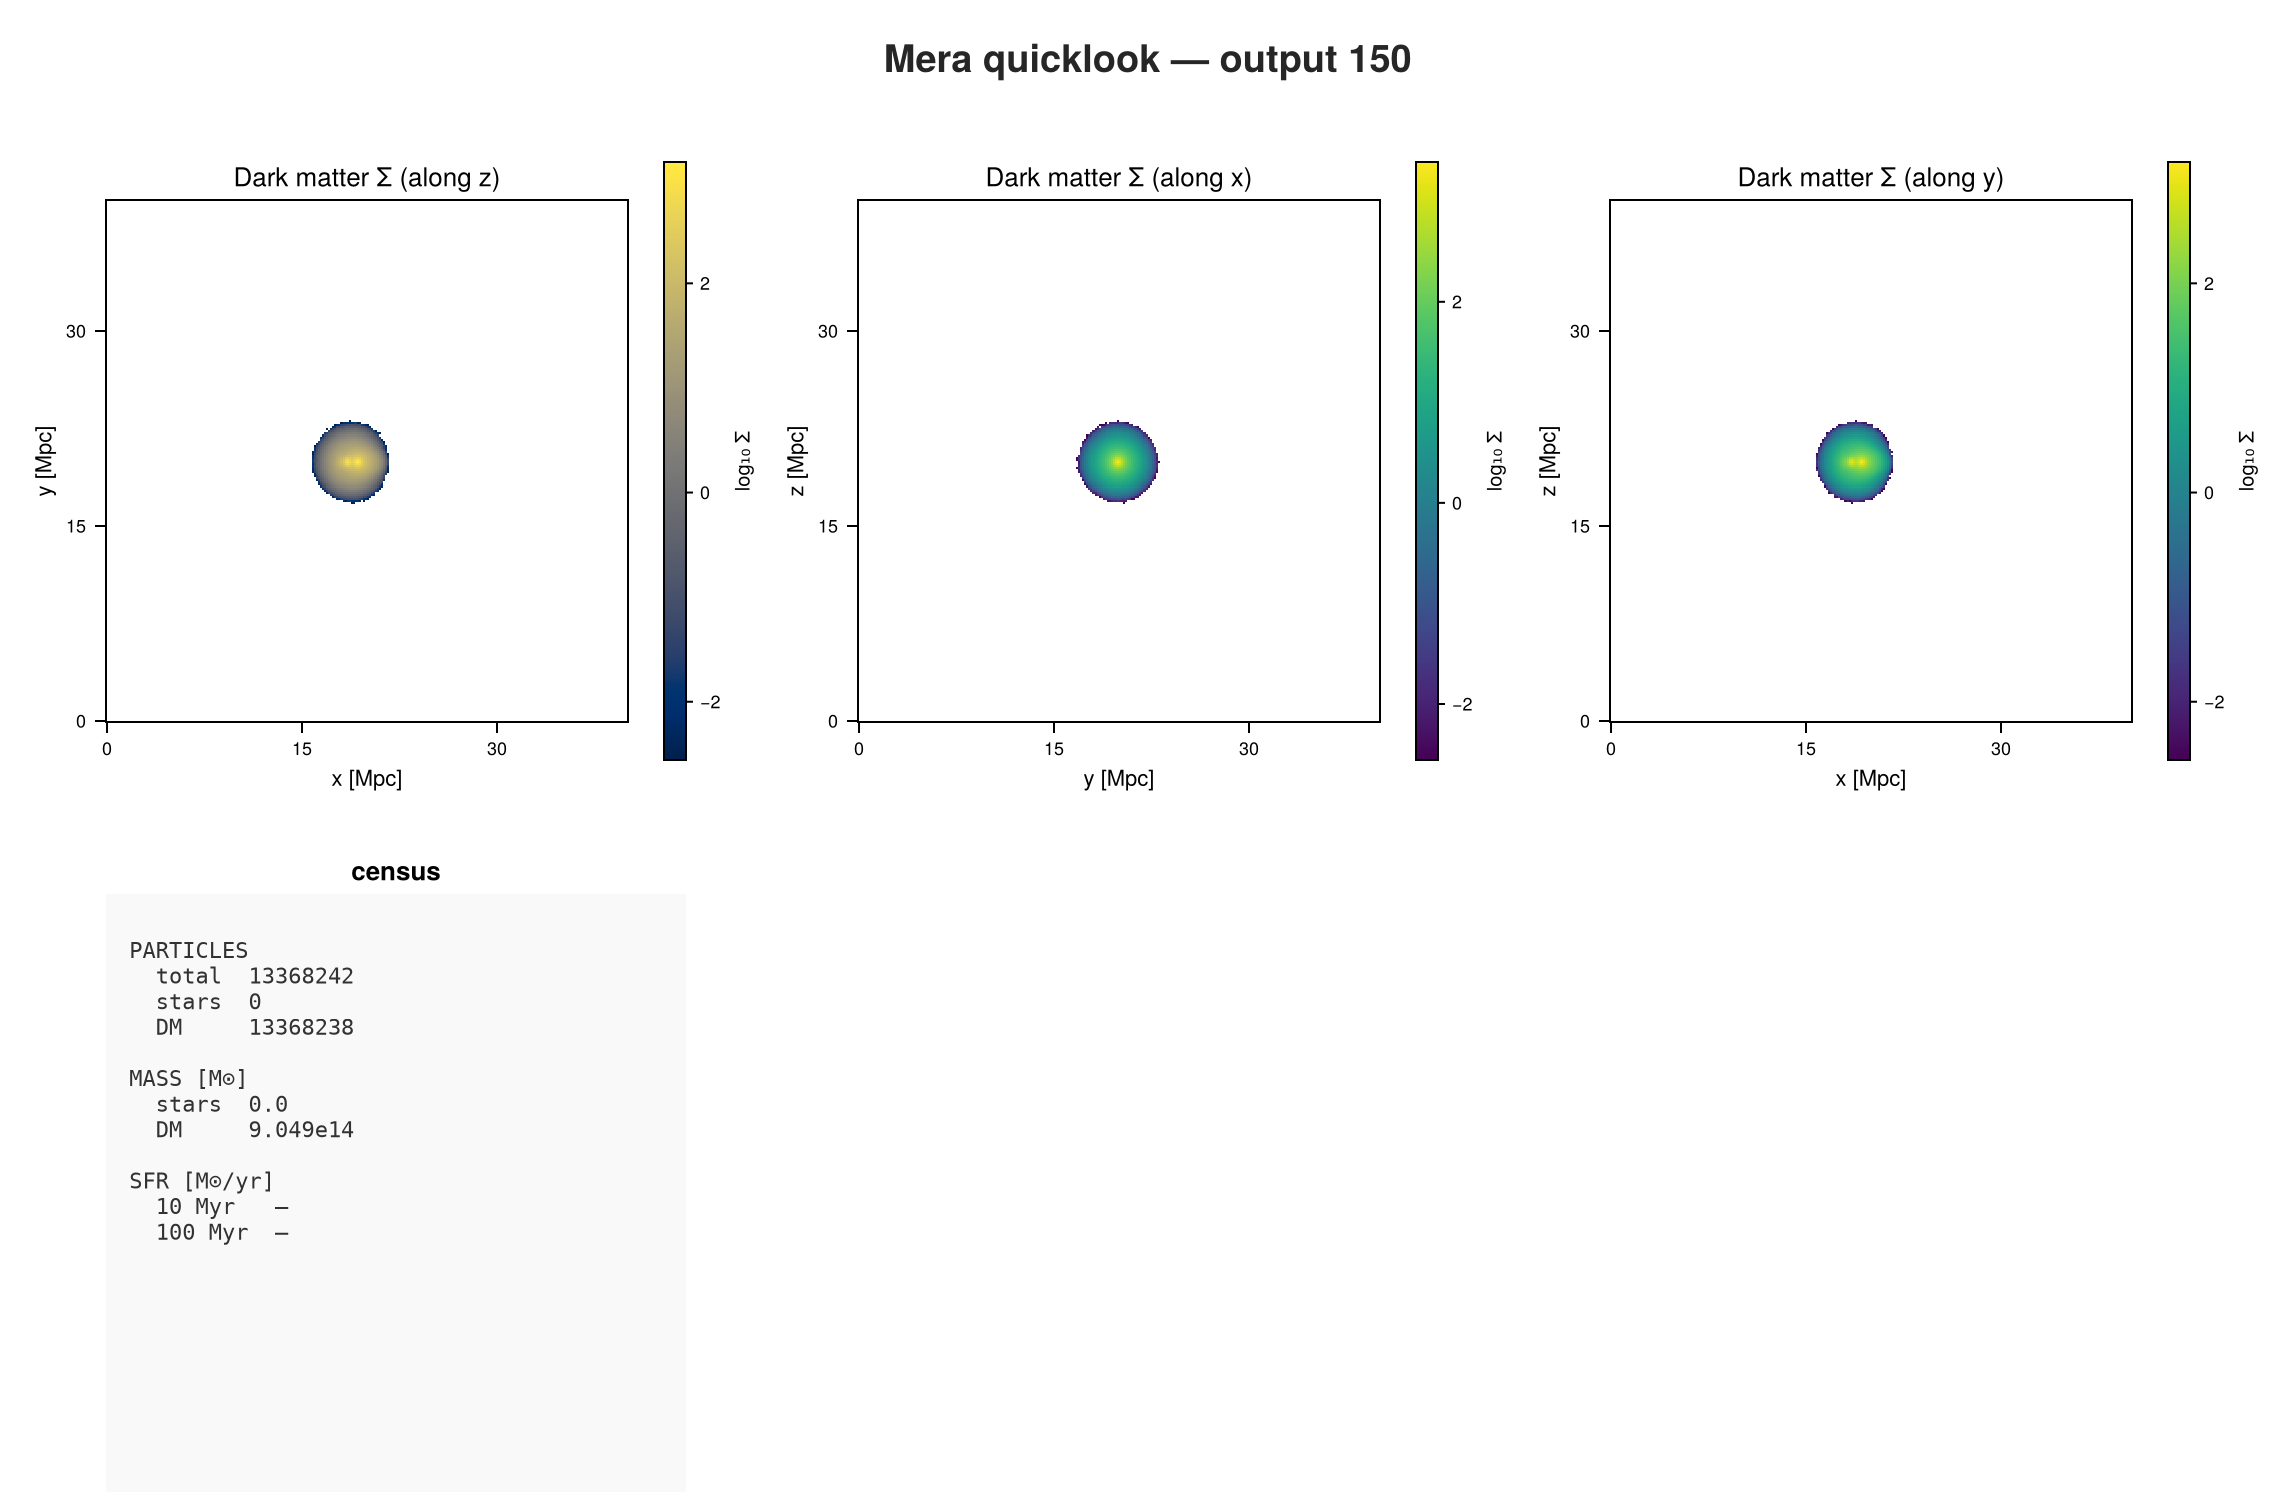

In [3]:
quicklookplot(ql)


The reader says it plainly: gas is `PartType0`, so it loads with `getparticles`, not `gethydro`.
This snapshot does record its units, so no fallback is needed. It does not record a gas
composition, so `:nH` uses the RAMSES convention, which the load message states.


In [4]:
capabilities(info)


4-element Vector{Symbol}:
 :info
 :particles
 :groups
 :logs

In [5]:
info.boxlen * info.scale.Mpc        # box size


39.99899430477804

## 2. Load the gas


In [6]:
gas = getparticles(info; families=[0]);


[Mera]: AREPO

 gas cells = 12865831, families 0  (x,y,z,vx,vy,vz,mass,id,family,rho,u,gpot,volume)


In [7]:
gas.data


Table with 12865831 rows, 13 columns:
Columns:
#   colname  type
────────────────────
1   x        Float64
2   y        Float64
3   z        Float64
4   vx       Float64
5   vy       Float64
6   vz       Float64
7   mass     Float64
8   id       Int64
9   family   Int32
10  rho      Float64
11  u        Float64
12  gpot     Float64
13  volume   Float64

Like GADGET, there is no `level`, `cx`, `cy`, `cz`: positions are ordinary numbers. Unlike
GADGET, these are not particles in the usual sense. Each row is a **cell**, and `:volume` is the
space it fills, derived as mass over density.


## 3. How much the cells vary

This is the thing to understand about a moving mesh. On an AMR grid, cell sizes change by factors
of two between levels. Here they vary continuously, and by a lot:


In [8]:
vol = getvar(gas, :volume);
extrema(vol)


(15.13118117840559, 1.097530975962345e9)

In [9]:
(maximum(vol) / minimum(vol))^(1/3)    # ratio of the largest to smallest cell, by length


417.0434630953461

A factor of several hundred in linear size, with no levels anywhere. That is why Mera stores
these as points carrying a volume rather than trying to fit them onto a grid: there is no grid
to fit them to.


## 4. Physical quantities

Everything downstream works as on any other code.


In [10]:
msum(gas, :Msol)                    # gas mass


1.8997890230846906e14

In [11]:
extrema(getvar(gas, :rho, :nH))     # cm^-3


(1.3970482530155927e-8, 0.01813816514293843)

Low densities across the board, which is right for the hot gas filling a cluster.


## 5. Temperature needs a composition

Temperature comes from the internal energy, and that needs the mean molecular weight. This
snapshot records no electron abundance, so Mera falls back to the RAMSES convention. For hot
cluster gas that is wrong by about a factor of two: the gas is fully ionised, so μ ≈ 0.6.

Say so, and it applies to the object you already loaded:


In [12]:
extrema(getvar(gas, :T, :K))        # default composition


(10.708062581365388, 5.571910085560703e8)

In [13]:
setcomposition!(gas; mu=0.6)        # fully ionised
extrema(getvar(gas, :T, :K))


(4.882876537102615, 2.5407909990156806e8)

Around 2.5×10⁸ K at the peak, which is the shock-heated gas in a cluster merger.

When a snapshot *does* carry an electron abundance, as IllustrisTNG data does, Mera uses it
per cell instead and there is nothing to set.

`:nH` is a separate question and needs no change here: it uses the hydrogen **mass fraction**,
and 0.76 is the primordial value AREPO assumes.


## 5. Projection: why the weighting matters here

A grid code projects a cell over the area it covers. A moving-mesh cell has no fixed footprint, so
Mera has to **deposit** it, and you choose how. The choice is visible, not cosmetic:


In [14]:
for w in (:mass, :sph, :voronoi)
    pr = projection(gas, :sd, :Msol_pc2; direction=:z, res=192, weighting=w,
                    verbose=false, show_progress=false)
    m  = pr.maps[:sd]
    println(rpad(string(w), 9), "  filled pixels: ",
            round(100*count(>(0), m)/length(m), digits=1), "%")
end


mass       filled pixels: 32.2%


sph        filled pixels: 100.0%


voronoi    filled pixels: 100.0%


- **`:mass`** drops each cell on one pixel. Fast and mass-conserving, but it leaves two thirds of
  the frame empty, because there are fewer cells than pixels in the sparse outskirts.
- **`:sph`** smears each cell over a kernel sized from its own volume. Smooth, mass-conserving,
  and the usual way moving-mesh data is rendered.
- **`:voronoi`** samples each line of sight through the nearest cell. Sharp and genuinely
  cell-respecting, and the slowest. Intensive maps such as temperature are exact this way, but
  surface density is approximate, so use `:sph` when column mass has to be conserved.

This is the one place where a grid code and a moving-mesh code genuinely differ, rather than
differing only in how the data is stored.


The map below uses `:sph`. Surface density has to conserve mass, and that is what `:sph` is for.
`:voronoi` is the sharper option, but its own documentation says surface density is only
approximate with it, so it belongs on intensive quantities such as temperature instead.


[Mera]: 2026-09-15T22:04:16.018

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]

Effective resolution: 512^2
Pixel size: 78.123 [kpc]
Simulation min.: 19.999 [Mpc]



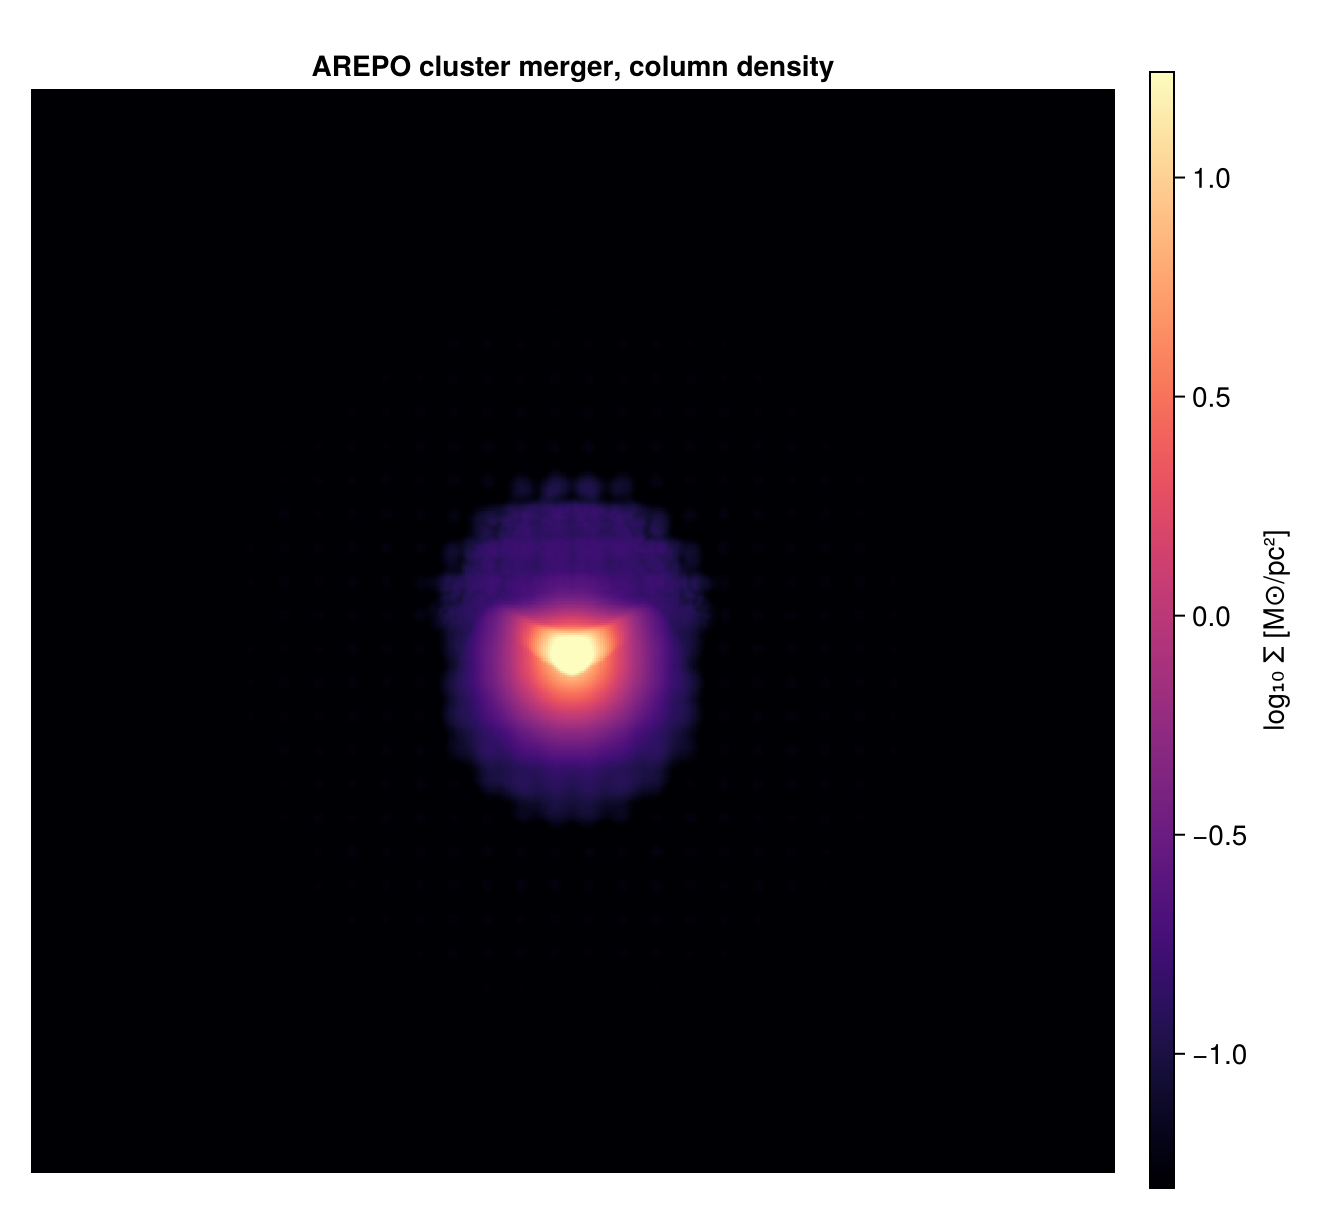

In [15]:
using Statistics

proj = projection(gas, :sd, :Msol_pc2; direction=:z, res=512, weighting=:sph);
L = log10.(proj.maps[:sd]);
lo, hi = quantile(vec(L), 0.90), quantile(vec(L), 0.999)

fig = Figure(size=(660, 610))
ax  = Axis(fig[1,1]; title="AREPO cluster merger, column density", aspect=DataAspect())
hidedecorations!(ax)
hm = heatmap!(ax, L'; colormap=:magma, colorrange=(lo, hi))
Colorbar(fig[1,2], hm, label="log₁₀ Σ [M⊙/pc²]")
fig


## Where to go next

A moving mesh reaches Mera as positions plus a volume, and from there the analysis is the same as
everywhere else. The one decision that is genuinely yours is the deposition when projecting.

The AREPO reader page covers the rest: SUBFIND catalogues, cosmological runs, IllustrisTNG data,
and `covering_grid` for resampling moving-mesh gas onto a regular grid.
